In [ ]:
# Standard library
import random
import matplotlib.pyplot as plt
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import math

# Custom utilities
from sklearn.preprocessing import StandardScaler

import utils.cross_validation as cval
import utils.exp_utils as exp
import xgboost as xgb
import shap
from matplotlib.patches import Patch

from math import radians, sin, cos, sqrt, asin


In [4]:
import os 

os.getcwd()

'/home/qli/Projects/FD_Stability'

In [5]:
biome_mapping = {
    'Temperate broadleaf forests': 'Temperate broadleaf forests',
    'Temperate conifer forests': 'Temperate conifer forests',
    'Temperate grasslands': 'Temperate grasslands',
    'Xeric shrublands': 'Xeric shrublands',
    'Mediterranean woodlands': 'Mediterranean woodlands',
    'Flooded grasslands': 'Flooded grasslands',
    'Mangroves': 'Mangroves',
    'Tundra': 'Boreal and Tundra forests',
    'Boreal forests or taiga': 'Boreal and Tundra forests',
    'Tropical grasslands': 'Tropical',
    'Tropical coniferous forests': 'Tropical',
    'Tropical moist broadleaf forests': 'Tropical',
    'Tropical dry broadleaf forests': 'Tropical',
    np.nan: np.nan,  # Will be dropped
}


biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
             "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
               "Mediterranean woodlands"]


In [6]:

fd_df = pd.read_csv('data/final/final_dataset_with_aridity.csv')
# fd_df.drop(columns=[ 'managed', 'ownership','Functional_Divergences', 'Shannon Equitabiltiy Index', 'DIA'], inplace=True)
fd_df.dropna(subset=['Raos_Q', 'Functional_Evenness', 'Soil Moisture',
                     'Species Richness', 'Shannon Diversity', "Simpson's Index", 'biome'], inplace=True)
fd_df.drop(columns=['ownership'], inplace=True)


ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

#Preprocessing the data for Random forest regression
# fbiome_dfs= data_processing_v2(fd_df, biome_mapping, ecoregions)

fd_df['biome'] = fd_df['biome'].map(biome_mapping) # Only run this once ! 

biome_dfs = {k: v for k, v in fd_df.groupby('biome')}



<Axes: >

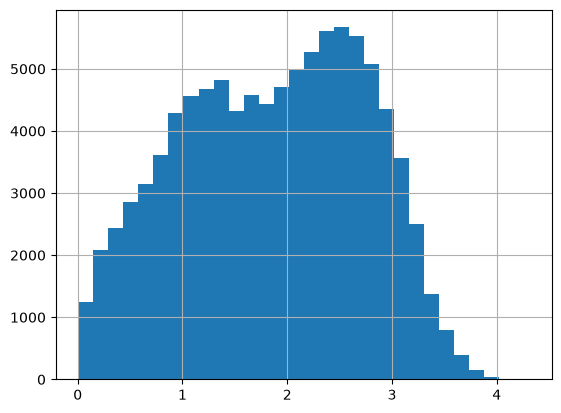

In [16]:
fd_df['Raos_Q'].hist(bins=30)

## XGBoost

## Global Model 

In [8]:
random_key=111

X=fd_df.drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome', 'BHAGE'])
y=fd_df['transformed npp'].values
scaler= StandardScaler()
scaler.fit_transform(X)
X = pd.DataFrame(
    X,
    columns=scaler.feature_names_in_
)

In [9]:
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=8,
    gamma=0.3,
    reg_lambda=2.0,
    reg_alpha=0.5,
    tree_method="hist",
    n_estimators=150,
)

model.fit(X, y )

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Mapping plot

In [ ]:
import plotly.express as px

# Define your feature list
feature_list = ['Raos_Q', 'Functional_Evenness', "Simpson's Index", 'Shannon Diversity']  

# Define colors
color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}

### Partial Dependence Plots

In [ ]:
explainer = shap.Explainer(model, approximate=True)

shap_vals = explainer.shap_values(X, approximate=True)
shap_values = explainer(X, approximate=True )


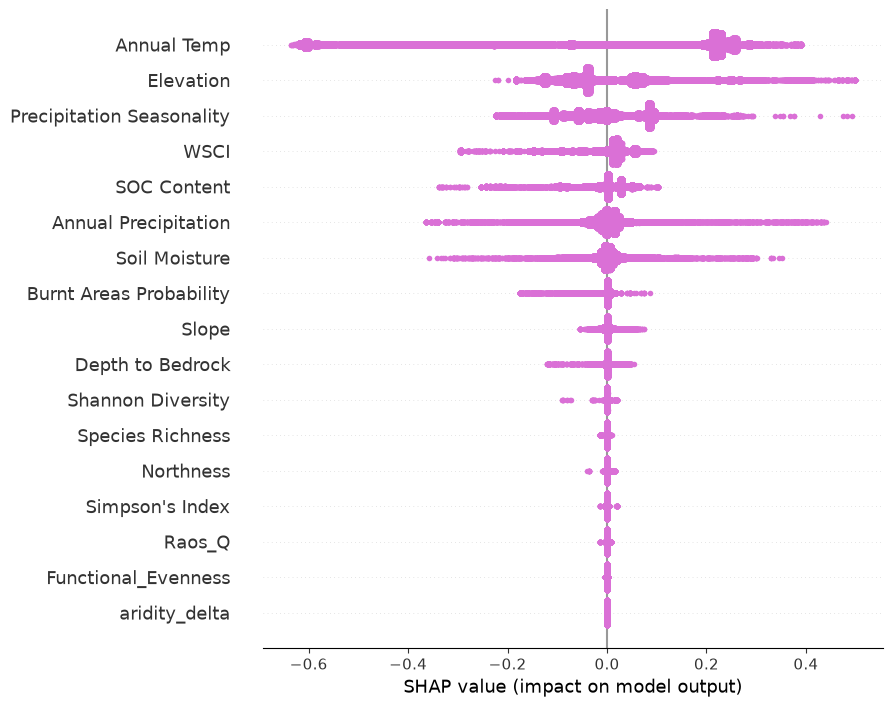

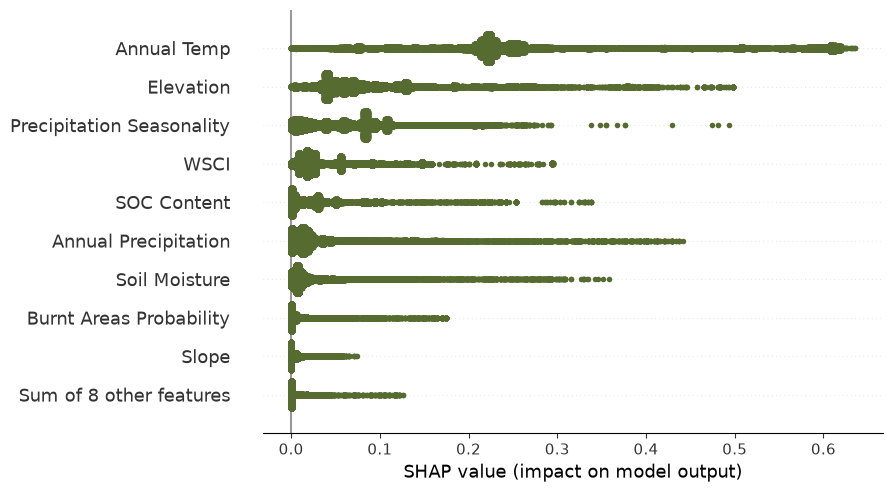

In [13]:
shap.plots.beeswarm(shap_values, color="orchid", max_display=None) #orchid vs darkolivegreen
shap.plots.beeswarm(shap_values.abs, color="darkolivegreen") #orchid vs darkolivegreen

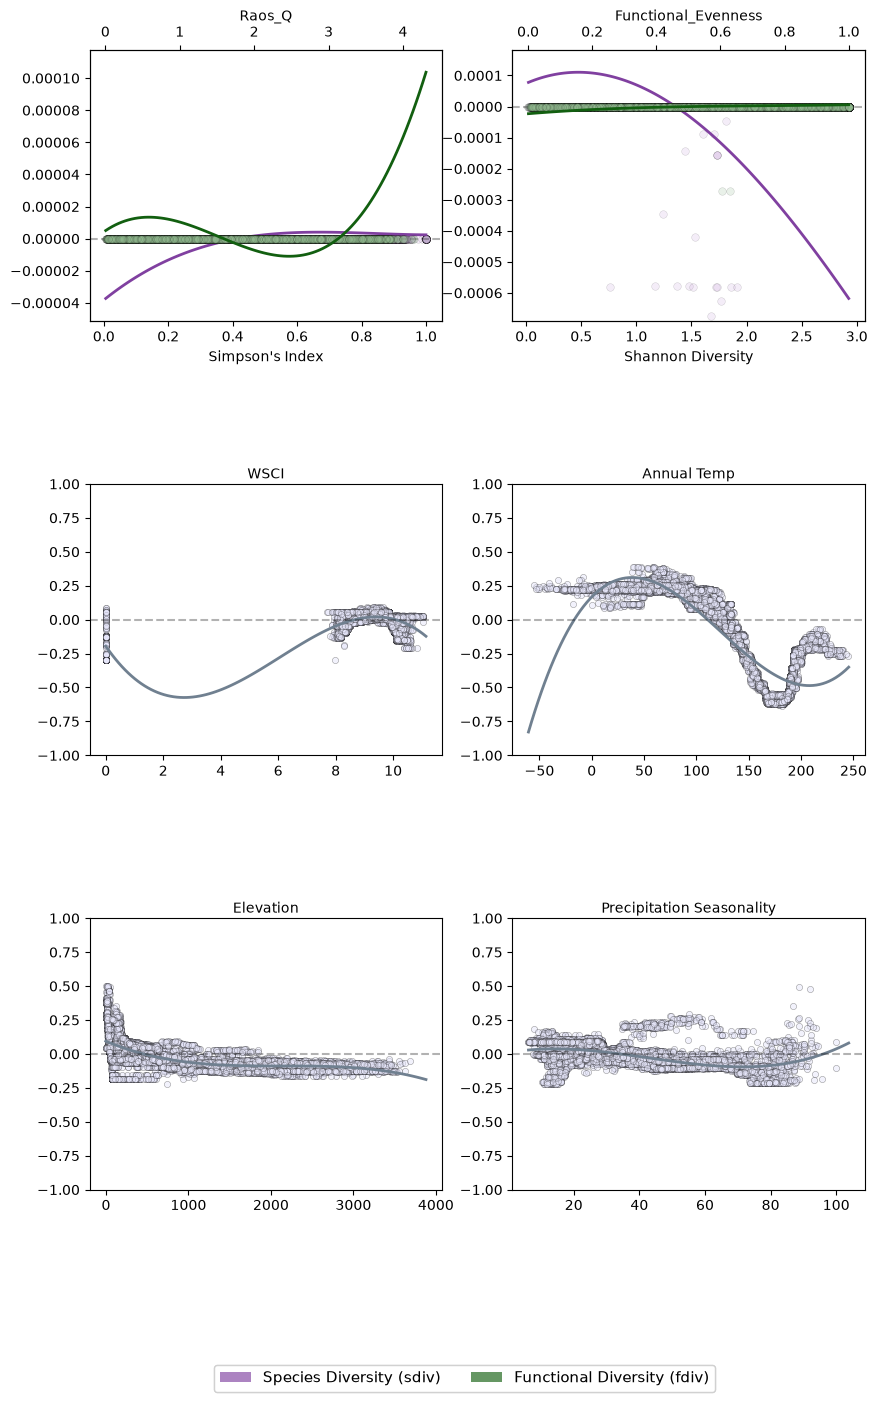

In [14]:
diversity_vars_f = ['Raos_Q', 'Functional_Evenness', 'WSCI', 'Annual Temp', 'Elevation', "Precipitation Seasonality"]

diversity_vars_s =  ["Simpson's Index", 'Shannon Diversity', 'WSCI',  'Annual Temp','Elevation', "Precipitation Seasonality"]

plot_shap_with_polynomial_stats_v2(shap_vals, X, diversity_vars_f, diversity_vars_s, degree=3)


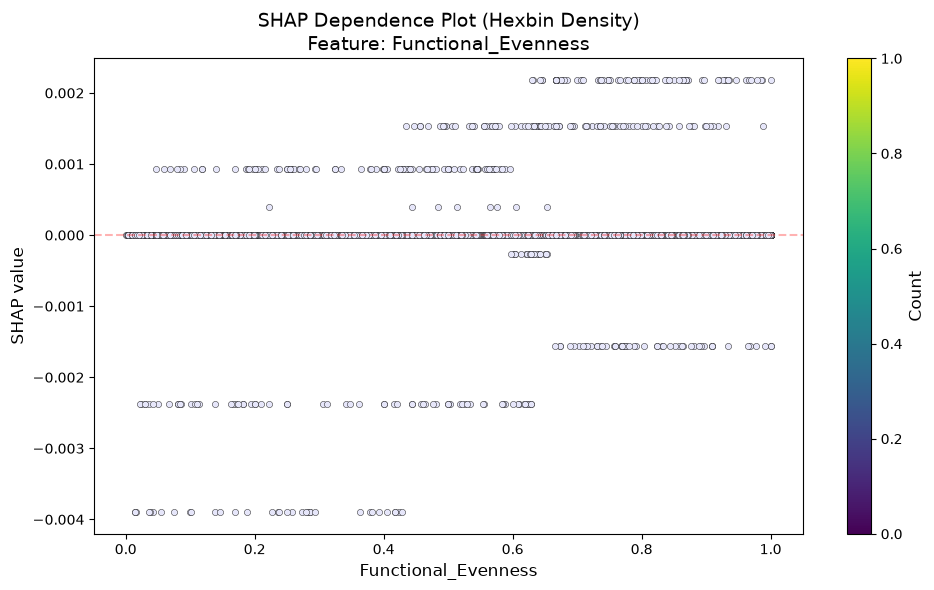

In [18]:

# Usage
fig, ax, shap_vals_feature, feature_vals = shap_dependence_hexbin('Functional_Evenness', shap_vals, X)
plt.show()

### UMap

In [34]:
from umap import UMAP

# compute 2D embedding of SHAP values
s_2d = UMAP(
  n_components=2, n_neighbors=30, min_dist=0.01, init='random', low_memory=True, random_state=random_key, n_jobs=-1
).fit_transform(shap_vals)


/home/qli/Projects/env1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


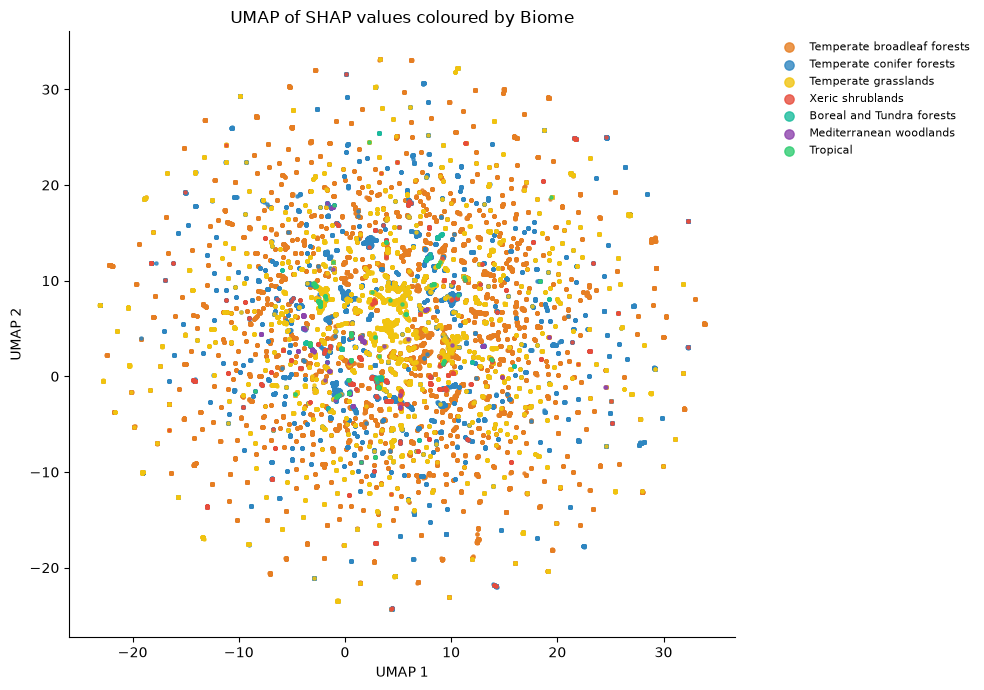

In [ ]:
# Assuming you have biome in your original dataframe
# e.g. df['biome'] or a separate series aligned to X

biome_colors = {
    'Temperate broadleaf forests': '#E67E22',      # Vibrant Orange
    'Temperate conifer forests': '#2E86C1',        # Bright Blue
    'Temperate grasslands': '#F1C40F',             # Bright Yellow
    'Xeric shrublands': '#E74C3C',                 # Bright Red
    'Boreal and Tundra forests': '#1ABC9C',        # Teal
    'Mediterranean woodlands': '#8E44AD',          # Purple
    'Tropical': '#2ECC71',                         # Emerald Green
    'Flooded grasslands': '#3498DB',               # Royal Blue
    'Mangroves': '#27AE60',                        # Dark Green
    'NaN': '#BDC3C7'                               # Light Gray
}
feature_list = ['Raos_Q',  "Simpson's Index", 
    'Functional_Evenness', 'Shannon Diversity', 
    'Species Richness', 'WSCI']

plot_all_umap(s_2d, fd_df, X, biome_colors, feature_list)

def plot_all_umap(s_2d, fd_df, X, biome_colors, feature_list,):

    plot_umap_by_features(s_2d, X, features=feature_list, name="figures/biome_umap_shap_biotic.png")

    features_list = [feat for feat in X.columns if feat not in features_list]

    plot_umap_by_features(s_2d, X, features=feature_list, name="figures/biome_umap_shap_abiotic.png")
    plot_umap_biome(s_2d, fd_df, biome_colors, name="figures/biome_umap_shap.png")

def plot_umap_by_features(s_2d, X, features, name="figures/umap_shap_features.png"):
    ncols = 4
    nrows = (len(features) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = axes.flatten()
    fig.subplots_adjust(hspace=0.5, wspace=0.4)

    for ax, feat in zip(axes_flat, features):
        sc = ax.scatter(
            s_2d[:, 0], s_2d[:, 1],
            c=X[feat].values,
            cmap='viridis',
            s=5,
            alpha=0.6
        )
        plt.colorbar(sc, ax=ax, label=feat)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.spines[['right', 'top']].set_visible(False)

    # Hide unused axes
    for ax in axes_flat[len(features):]:
        ax.set_visible(False)

    plt.suptitle("UMAP of SHAP values coloured by feature", fontsize=13, y=1.02)
    plt.savefig(name, dpi=150, bbox_inches="tight")


def plot_umap_biome(s_2d, fd_df, biome_colors, name="figures/umap_shap_biome.png"):
    """
    Plots a 2D UMAP embedding of SHAP values colored by biome.

    Parameters:
    - s_2d: 2D numpy array of UMAP embeddings.
    - fd_df: DataFrame containing the original data with a 'biome' column.
    - biome_colors: Dictionary mapping biome names to colors.
    """

    fig, ax = plt.subplots(figsize=(10, 7))
    biomes =  fd_df['biome'].values  # numpy array of biome labels per row
    for biome, color in biome_colors.items():
        mask = biomes == biome
        if mask.sum() == 0:
            continue
        ax.scatter(
            s_2d[mask, 0], s_2d[mask, 1],
            color=color,
            s=5,
            alpha=0.8,
            label=biome
        )

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title("UMAP of SHAP values coloured by Biome")
    ax.legend(
        markerscale=3,
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=False,
        fontsize=8
    )
    ax.spines[['right', 'top']].set_visible(False)

    plt.tight_layout()
    plt.savefig(name, dpi=150, bbox_inches="tight")


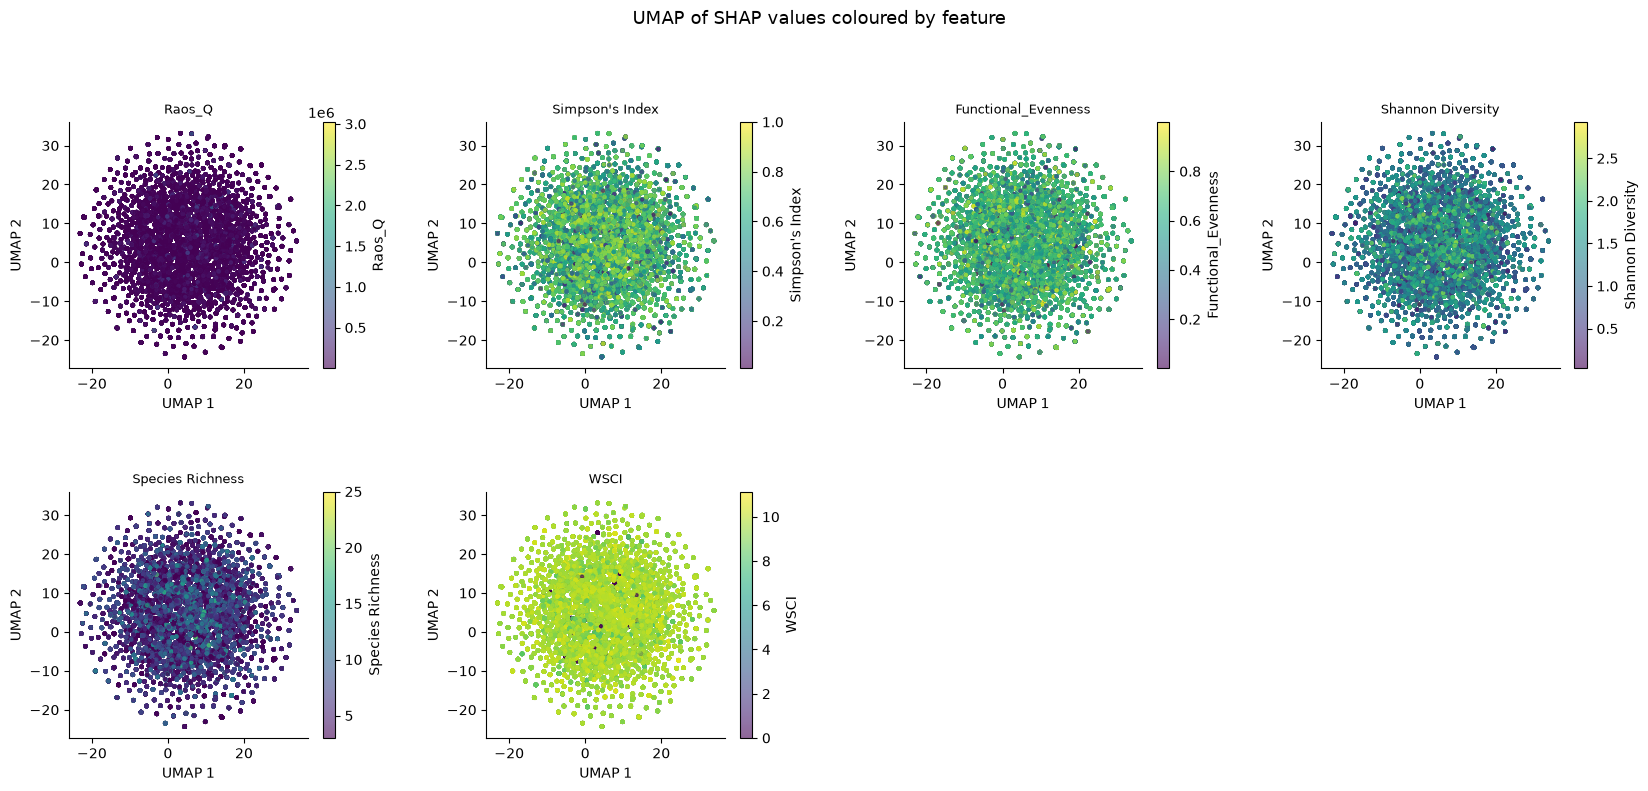

In [ ]:
features = ['Raos_Q',  "Simpson's Index", 
    'Functional_Evenness', 'Shannon Diversity', 
    'Species Richness', 'WSCI']

# features = [feat for feat in X.columns if feat not in features]


In [37]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import KBinsDiscretizer

features = ['Raos_Q', "Simpson's Index", 'Functional_Evenness', 
            'Shannon Diversity', 'Species Richness', 'WSCI',
            'Precipitation Seasonality', 'SOC Content']

est = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')

for feat in features:
    vals = X[feat].values.reshape(-1, 1)
    labels = est.fit_transform(vals).astype(int).flatten()
    score = silhouette_score(s_2d, labels, sample_size=10000, random_state=42)
    print(f"{feat:30s} Silhouette: {score:.3f}")

Raos_Q                         Silhouette: 0.003
Simpson's Index                Silhouette: 0.006
Functional_Evenness            Silhouette: 0.000
Shannon Diversity              Silhouette: 0.006
Species Richness               Silhouette: 0.012
WSCI                           Silhouette: 0.010
Precipitation Seasonality      Silhouette: 0.011
SOC Content                    Silhouette: 0.020


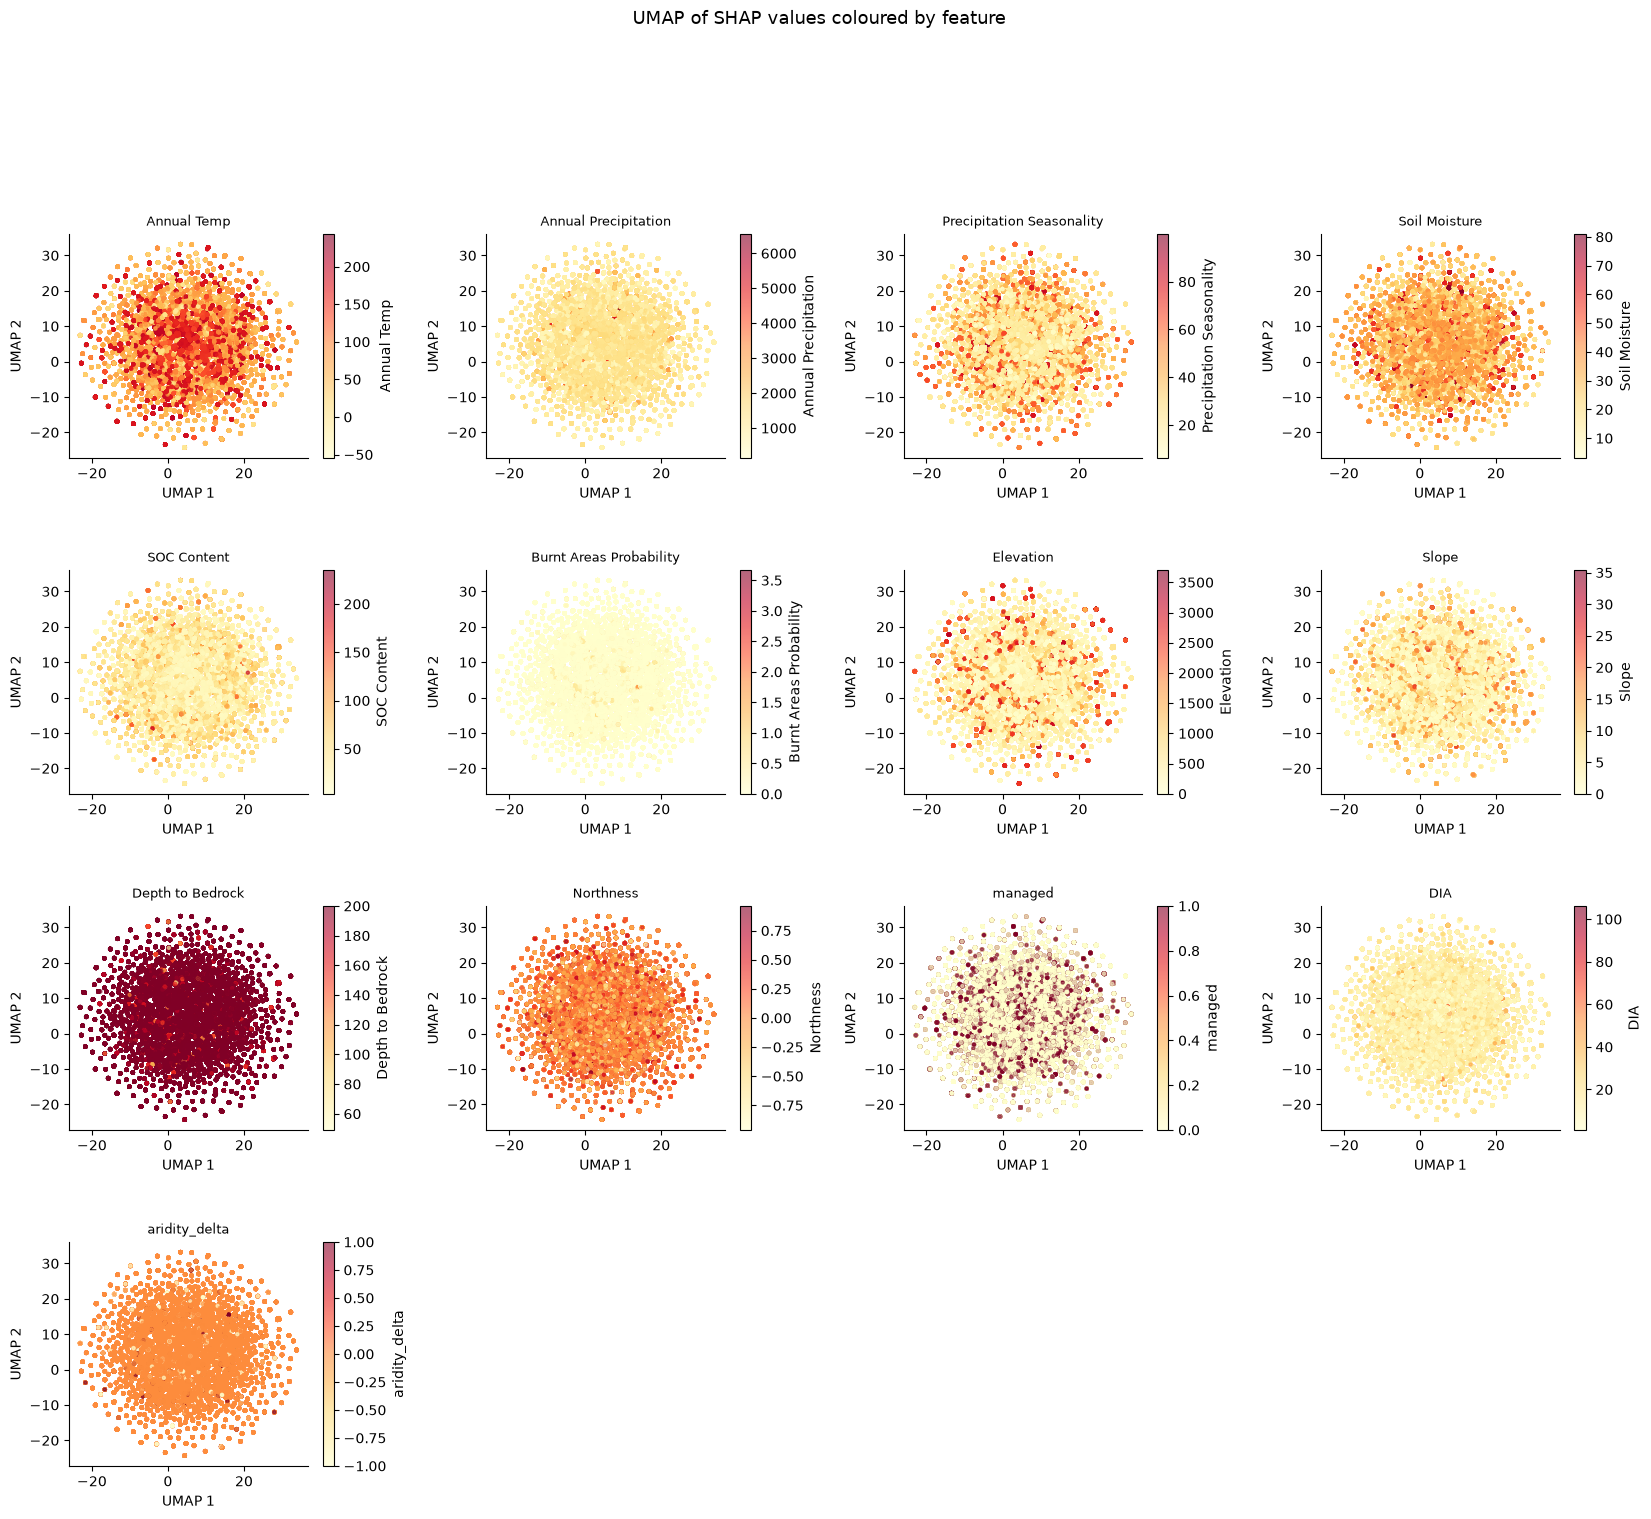

In [38]:
features = ['Raos_Q',  "Simpson's Index", 
    'Functional_Evenness', 'Shannon Diversity', 
    'Species Richness', 'WSCI']

features = [feat for feat in X.columns if feat not in features]

ncols = 4
nrows = (len(features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()
fig.subplots_adjust(hspace=0.5, wspace=0.4)

for ax, feat in zip(axes_flat, features):
    sc = ax.scatter(
        s_2d[:, 0], s_2d[:, 1],
        c=X[feat].values,
        cmap='YlOrRd',
        s=5,
        alpha=0.6
    )
    plt.colorbar(sc, ax=ax, label=feat)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.spines[['right', 'top']].set_visible(False)

# Hide unused axes
for ax in axes_flat[len(features):]:
    ax.set_visible(False)

plt.suptitle("UMAP of SHAP values coloured by feature", fontsize=13, y=1.02)
# plt.savefig("umap_shap.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import silhouette_score

biome_labels = fd_df['biome'].values

features = ['Raos_Q', "Simpson's Index", 'Functional_Evenness', 
            'Shannon Diversity', 'Species Richness', 'WSCI'  ]

est = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile',  quantile_method='averaged_inverted_cdf')

results = []

for biome in biome_list:
    mask = biome_labels == biome
    X_filtered = X[mask]
    s_2d_filtered = s_2d[mask]
    n = len(s_2d_filtered)
    
    # Skip biomes with too few samples
    if n < 50:
        print(f"Skipping {biome}: only {n} samples")
        continue
    
    for feat in features:
        try:
            vals = X_filtered[feat].values.reshape(-1, 1)
            labels = est.fit_transform(vals).astype(int).flatten()
            
            # Skip if only one class after binning
            if len(set(labels)) < 2:
                continue
                
            score = silhouette_score(s_2d_filtered, labels, random_state=42)
            results.append({'biome': biome, 'feature': feat, 'silhouette': score, 'n': n})
            
        except Exception as e:
            print(f"Failed {biome} / {feat}: {e}")

# Summarise as a readable table
results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='biome', columns='feature', values='silhouette').round(3)


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:334: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [51]:
pivot

feature,Functional_Evenness,Raos_Q,Shannon Diversity,Simpson's Index,Species Richness,WSCI
biome,,,,,,
Boreal and Tundra forests,-0.002,0.154,-0.003,-0.006,NaN,NaN
Mediterranean woodlands,0.031,0.006,-0.007,-0.000,NaN,0.067
Temperate broadleaf forests,0.005,0.002,0.017,0.013,0.041,0.014
Temperate conifer forests,0.003,0.002,0.001,0.001,0.013,0.005
Temperate grasslands,0.002,0.000,0.004,0.003,0.004,0.022
Tropical,0.055,0.041,0.067,0.051,0.096,0.160
Xeric shrublands,0.001,0.003,0.005,0.006,NaN,0.061


In [55]:
# Silhouette on raw SHAP, not 2D UMAP embedding
from sklearn.cluster import KMeans
labels = KMeans(n_clusters=4).fit_predict(shap_vals)

from sklearn.metrics import silhouette_score
score = silhouette_score(shap_vals, labels)  # often higher than on UMAP

KeyboardInterrupt: 

### Localised Models 

Training and evaluating for biome: Xeric shrublands


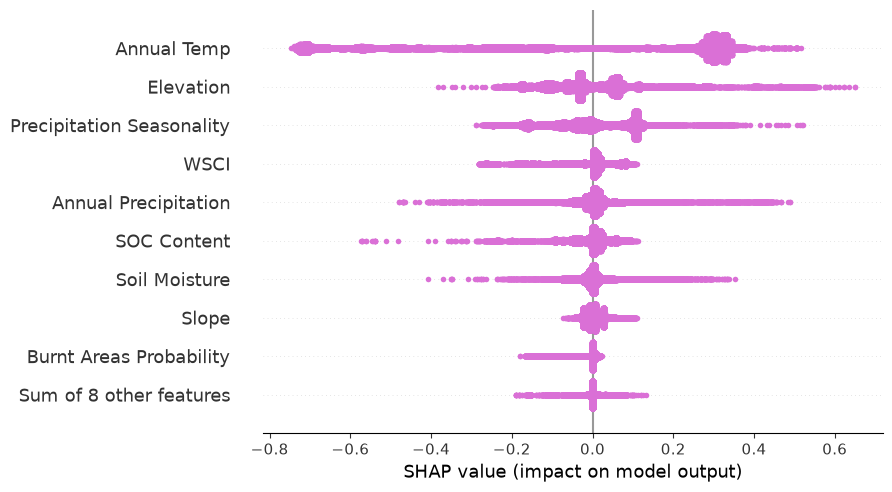

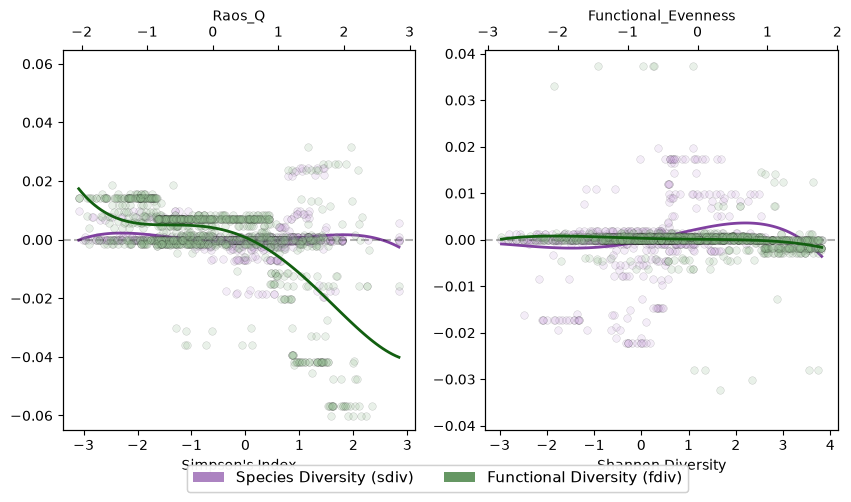

Training and evaluating for biome: Boreal and Tundra forests


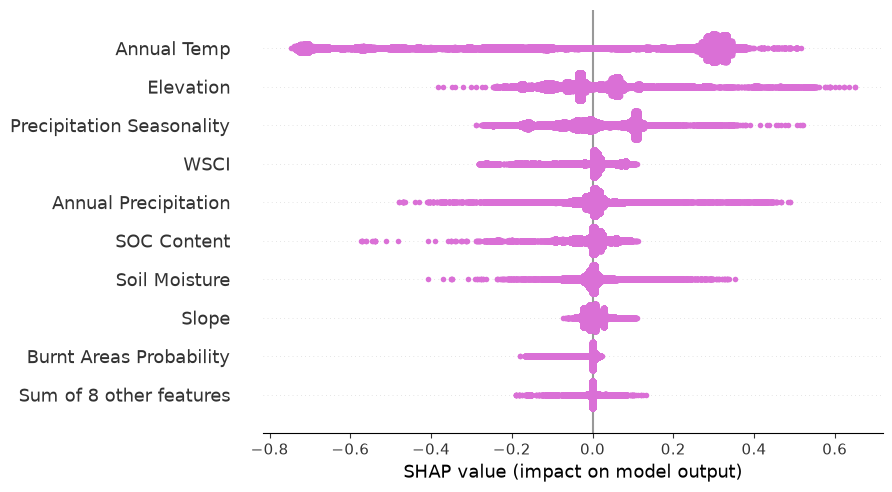

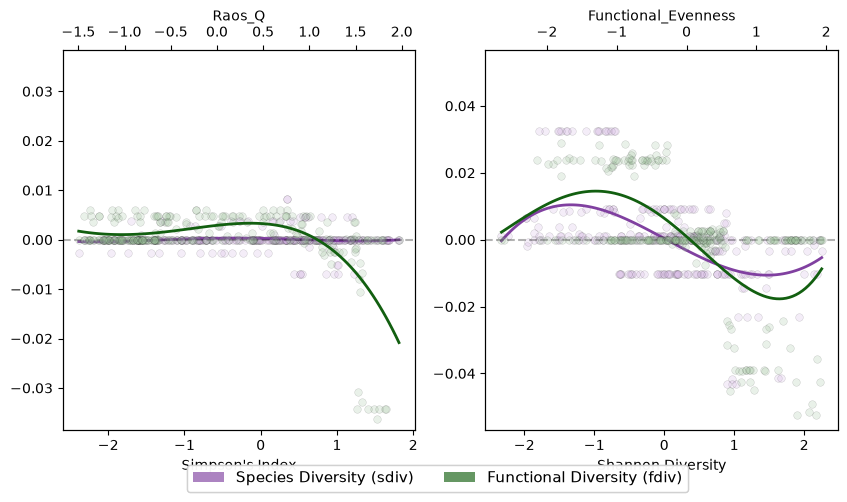

Training and evaluating for biome: Tropical


KeyboardInterrupt: 

In [38]:
XGB_CONFIGS = {
    'Temperate conifer forests': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.05,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx',
            'n_estimators': 200,
        },
        'early_stopping_rounds': 20,
        'description': 'Default configuration'
    },
    'Boreal and Tundra forests': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.02,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx',
            'n_estimators': 90,
        },
        'early_stopping_rounds': 10,
        'description': 'Regularized for small dataset'
    },
    'Xeric shrublands': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.01,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx',
            'n_estimators': 100,
        },
        'early_stopping_rounds': 10,
        'description': 'Regularized for small dataset'
    },
    'Temperate grasslands': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.01,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx',
            'n_estimators': 250,
        },
        'early_stopping_rounds': 15,
        'description': 'Regularized with more rounds'
    },
    'Mediterranean woodlands': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.005,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx',
            'n_estimators': 150,
        },
        'early_stopping_rounds': 10,
        'description': 'Regularized for small dataset (RF better)'
    },
    'Temperate broadleaf forests': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.01,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 3.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx',
            'n_estimators': 380,
        },
        'early_stopping_rounds': 5,
        'description': 'NA'
    },
    'Tropical': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.01,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx',
            'n_estimators': 330,
        },
        'early_stopping_rounds': 30,
        'description': 'Large dataset - more rounds'
    }
}

random_key=42
# Select biome
biome_list= ["Xeric shrublands", "Boreal and Tundra forests", "Tropical",
             "Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
               "Mediterranean woodlands"]

for biome in biome_list:
    print(f"Training and evaluating for biome: {biome}")

    cfg = XGB_CONFIGS[biome]

    df= biome_dfs[biome]

    X=df.drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome', 'BHAGE'])
    y=df['transformed npp'].values
    scaler= StandardScaler()
    X=scaler.fit_transform(X)
    
    X = pd.DataFrame(
        X,
        columns=scaler.feature_names_in_
    )
    model = xgb.XGBRegressor(**cfg['params'])

    model.fit(X, y)

    diversity_vars_f = ['Raos_Q', 'Functional_Evenness']
    diversity_vars_s = ["Simpson's Index", 'Shannon Diversity']
    
    explainer = shap.TreeExplainer(model, approximate=True)

    shap_vals = explainer.shap_values(X, approximate=True)

    shap.plots.beeswarm(shap_values, color="orchid") 

    # plt.figure(figsize=(8, 8))
    # shap.summary_plot(shap_vals, X)
    # plt.show()
    plot_shap_with_polynomial_stats_v2(shap_vals, X, diversity_vars_f, diversity_vars_s, degree=4)

